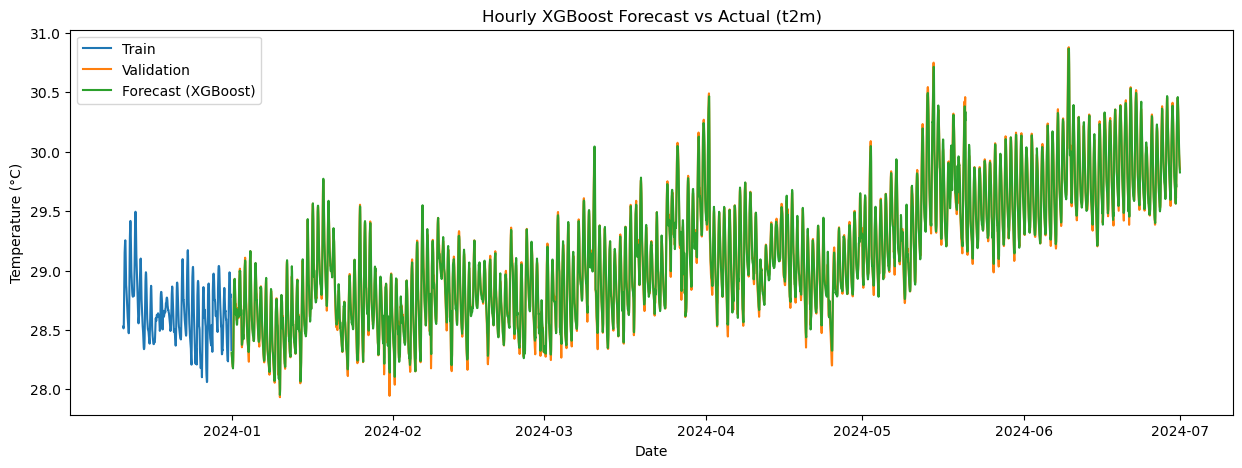

MAE: 0.03376388394436122
RMSE: 0.04917029293606768


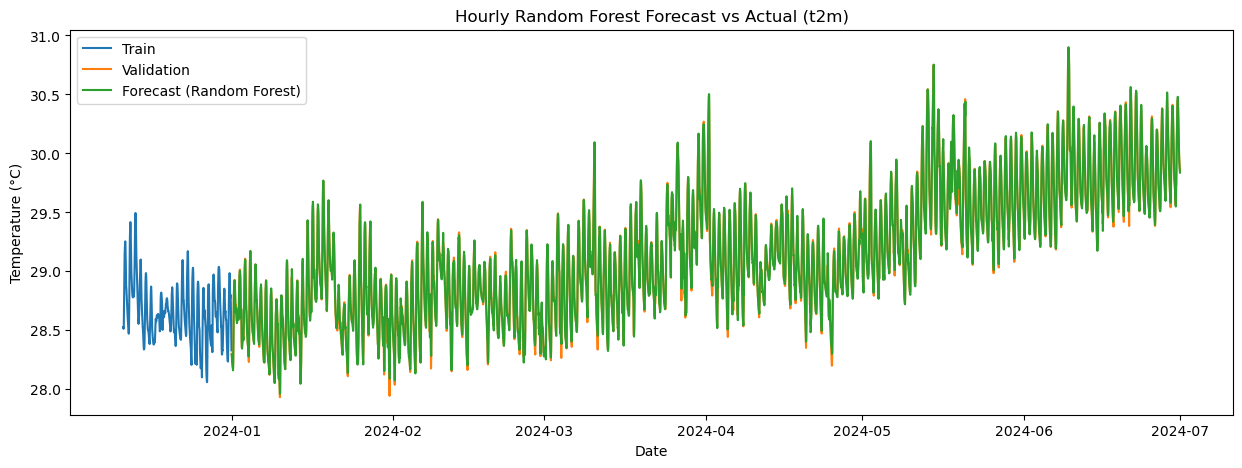

MAE: 0.029032313904682215
RMSE: 0.04507478714688207


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("../data/processed/sfax_weather_features.csv", parse_dates=['valid_time'])
df = df.set_index('valid_time')

#XGBoost fot t2m:
def create_lag_features(df, target_col, lags):
    for lag in lags:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)
    return df

lags = list(range(1, 25))
df = create_lag_features(df.copy(), 't2m', lags)
df = df.dropna()

train = df.loc[:'2023-12-31']
val = df.loc['2024-01-01':'2024-06-30']

X_train = train[[f"t2m_lag_{lag}" for lag in lags]]
y_train = train['t2m']
X_val = val[[f"t2m_lag_{lag}" for lag in lags]]
y_val = val['t2m']

model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

plt.figure(figsize=(15,5))
plt.plot(y_train.index[-500:], y_train.values[-500:], label='Train')
plt.plot(y_val.index, y_val.values, label='Validation')
plt.plot(y_val.index, y_pred, label='Forecast (XGBoost)')

plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Hourly XGBoost Forecast vs Actual (t2m)')
plt.legend()
plt.show()

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
#RFR
def create_lag_features(df, target_col, lags):
    for lag in lags:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)
    return df

lags = list(range(1, 25))
df = create_lag_features(df.copy(), 't2m', lags)
df = df.dropna()

train = df.loc[:'2023-12-31']
val = df.loc['2024-01-01':'2024-06-30']

X_train = train[[f"t2m_lag_{lag}" for lag in lags]]
y_train = train['t2m']
X_val = val[[f"t2m_lag_{lag}" for lag in lags]]
y_val = val['t2m']

model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_val)

plt.figure(figsize=(15,5))
plt.plot(y_train.index[-500:], y_train.values[-500:], label='Train')
plt.plot(y_val.index, y_val.values, label='Validation')
plt.plot(y_val.index, y_pred_rf, label='Forecast (Random Forest)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Hourly Random Forest Forecast vs Actual (t2m)')
plt.legend()
plt.show()

mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
print(f"MAE: {mae_rf}")
print(f"RMSE: {rmse_rf}")
